## RUN POSITIONAL ENCODING VARIANTS

In [1]:
import torch
import json 
import time
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

from pathlib import Path
from itertools import islice
sys.path.append(os.path.abspath('..'))

In [2]:
from src.model import ToyModel
from src.train import train_pe_variants
from src.test import test_model

In [3]:


batch_size = 32
seq_len = 10
vocab_size = 100

# X shape: (32, 10)
X = torch.randint(low=0, high=vocab_size, size=(batch_size, seq_len))


X_val = torch.randint(low=0, high=vocab_size, size=(batch_size, seq_len))


# Generate Y as the reversal of X
Y = X.flip(dims=[1])
Y_val = X_val.flip(dims=[1])

X_test = torch.randint(low=0, high=vocab_size, size=(batch_size, 50))
Y_test = X_test.flip(dims=[1])



### PE VARIANTS

In [4]:
# Sinusoidal Encoding
model = ToyModel(512,1000,100,"sinusoidal")

history = train_pe_variants(model,X,X_val,Y,Y_val,"sinusoidal")

accuracy = test_model(model,X_test,Y_test)
print(f"Sinusoidal encoding Accuracy: {accuracy}")

Epoch 1/40 | Train Loss: 6.9175 | Train Accuracy: 0.00%
Epoch 1/40 | Val Loss: 6.5364 | Val Accuracy: 2.50%
Epoch 2/40 | Train Loss: 3.1687 | Train Accuracy: 8.44%
Epoch 2/40 | Val Loss: 5.9303 | Val Accuracy: 3.12%
Epoch 3/40 | Train Loss: 2.7561 | Train Accuracy: 8.12%
Epoch 3/40 | Val Loss: 5.2625 | Val Accuracy: 2.50%
Epoch 4/40 | Train Loss: 2.2955 | Train Accuracy: 6.25%
Epoch 4/40 | Val Loss: 5.0784 | Val Accuracy: 2.50%
Epoch 5/40 | Train Loss: 2.0797 | Train Accuracy: 12.19%
Epoch 5/40 | Val Loss: 4.9168 | Val Accuracy: 2.50%
Epoch 6/40 | Train Loss: 1.9233 | Train Accuracy: 18.44%
Epoch 6/40 | Val Loss: 4.8512 | Val Accuracy: 2.50%
Epoch 7/40 | Train Loss: 1.8304 | Train Accuracy: 16.88%
Epoch 7/40 | Val Loss: 4.8351 | Val Accuracy: 3.12%
Epoch 8/40 | Train Loss: 1.7096 | Train Accuracy: 26.56%
Epoch 8/40 | Val Loss: 4.8729 | Val Accuracy: 4.06%
Epoch 9/40 | Train Loss: 1.5473 | Train Accuracy: 27.50%
Epoch 9/40 | Val Loss: 4.9531 | Val Accuracy: 4.69%
Epoch 10/40 | Train Los

In [5]:
#Learned Encoding
model = ToyModel(512,1000,100,"learned")

history = train_pe_variants(model,X,X_val,Y,Y_val,"learned")
accuracy = test_model(model,X_test,Y_test)

print(f"Learned encoding Accuracy: {accuracy}")

Epoch 1/40 | Train Loss: 6.9060 | Train Accuracy: 0.00%
Epoch 1/40 | Val Loss: 6.7253 | Val Accuracy: 1.88%
Epoch 2/40 | Train Loss: 3.2320 | Train Accuracy: 26.56%
Epoch 2/40 | Val Loss: 6.4154 | Val Accuracy: 2.50%
Epoch 3/40 | Train Loss: 2.9310 | Train Accuracy: 34.69%
Epoch 3/40 | Val Loss: 5.8487 | Val Accuracy: 3.75%
Epoch 4/40 | Train Loss: 2.4726 | Train Accuracy: 34.69%
Epoch 4/40 | Val Loss: 5.1622 | Val Accuracy: 3.75%
Epoch 5/40 | Train Loss: 1.9414 | Train Accuracy: 30.31%
Epoch 5/40 | Val Loss: 4.9324 | Val Accuracy: 5.00%
Epoch 6/40 | Train Loss: 1.6119 | Train Accuracy: 32.81%
Epoch 6/40 | Val Loss: 4.7770 | Val Accuracy: 9.69%
Epoch 7/40 | Train Loss: 1.3406 | Train Accuracy: 50.94%
Epoch 7/40 | Val Loss: 4.6120 | Val Accuracy: 13.44%
Epoch 8/40 | Train Loss: 1.0868 | Train Accuracy: 70.62%
Epoch 8/40 | Val Loss: 4.5278 | Val Accuracy: 9.69%
Epoch 9/40 | Train Loss: 0.8637 | Train Accuracy: 80.31%
Epoch 9/40 | Val Loss: 4.5084 | Val Accuracy: 10.62%
Epoch 10/40 | Trai

In [6]:
#NO PE Encoding
model = ToyModel(512,1000,100,None)

history = train_pe_variants(model,X,X_val,Y,Y_val,"NO_PE")
accuracy = test_model(model,X_test,Y_test)
print(f"NO encoding Accuracy: {accuracy}")

Epoch 1/40 | Train Loss: 6.9041 | Train Accuracy: 0.00%
Epoch 1/40 | Val Loss: 6.8157 | Val Accuracy: 2.81%
Epoch 2/40 | Train Loss: 3.3295 | Train Accuracy: 18.75%
Epoch 2/40 | Val Loss: 6.7151 | Val Accuracy: 5.62%
Epoch 3/40 | Train Loss: 3.1877 | Train Accuracy: 28.44%
Epoch 3/40 | Val Loss: 6.5670 | Val Accuracy: 5.62%
Epoch 4/40 | Train Loss: 2.9963 | Train Accuracy: 30.94%
Epoch 4/40 | Val Loss: 6.3429 | Val Accuracy: 5.31%
Epoch 5/40 | Train Loss: 2.7311 | Train Accuracy: 31.87%
Epoch 5/40 | Val Loss: 6.0297 | Val Accuracy: 5.62%
Epoch 6/40 | Train Loss: 2.3954 | Train Accuracy: 32.19%
Epoch 6/40 | Val Loss: 5.6504 | Val Accuracy: 4.69%
Epoch 7/40 | Train Loss: 2.0295 | Train Accuracy: 32.81%
Epoch 7/40 | Val Loss: 5.2347 | Val Accuracy: 5.31%
Epoch 8/40 | Train Loss: 1.6667 | Train Accuracy: 37.81%
Epoch 8/40 | Val Loss: 4.9359 | Val Accuracy: 5.31%
Epoch 9/40 | Train Loss: 1.3891 | Train Accuracy: 41.25%
Epoch 9/40 | Val Loss: 4.7993 | Val Accuracy: 6.25%
Epoch 10/40 | Train 

In [7]:
# 1. Create a fresh No-PE model
no_pe_model = ToyModel(d_model=128, vocab_size=100, max_len=100, pe_type='none')
no_pe_model.eval()

# 2. "I love cats" -> [1, 2, 3]
seq_A = torch.tensor([[1, 2, 3]])

# 3. "cats love I" -> [3, 2, 1]
seq_B = torch.tensor([[3, 2, 1]])

with torch.no_grad():
    out_A, _ = no_pe_model(seq_A)
    out_B, _ = no_pe_model(seq_B)
    
    # Let's look at the output vector for the word "love" (ID 2).
    # In seq_A, "love" is at position 1. In seq_B, "love" is at position 1.
    print("Vector for 'love' in Seq A:", out_A[0, 1, :5]) 
    print("Vector for 'love' in Seq B:", out_B[0, 1, :5])

Vector for 'love' in Seq A: tensor([ 0.1181,  0.0590, -0.0158, -0.0364,  0.0081])
Vector for 'love' in Seq B: tensor([ 0.1181,  0.0590, -0.0158, -0.0364,  0.0081])


In [8]:
# 1. Create a fresh PE model
no_pe_model = ToyModel(d_model=128, vocab_size=100, max_len=100, pe_type='sinusoidal')
no_pe_model.eval()

# 2. "I love cats" -> [1, 2, 3]
seq_A = torch.tensor([[1, 2, 3]])

# 3. "cats love I" -> [3, 2, 1]
seq_B = torch.tensor([[3, 2, 1]])

with torch.no_grad():
    out_A, _ = no_pe_model(seq_A)
    out_B, _ = no_pe_model(seq_B)
    
    # Let's look at the output vector for the word "love" (ID 2).
    # In seq_A, "love" is at position 1. In seq_B, "love" is at position 1.
    print("Vector for 'love' in Seq A:", out_A[0, 1, 90:]) 
    print("Vector for 'love' in Seq B:", out_B[0, 1, 90:])

Vector for 'love' in Seq A: tensor([-0.1237, -0.2775,  0.1518, -0.0178,  0.1674,  0.1926, -0.0308, -0.0481,
         0.1178, -0.1895])
Vector for 'love' in Seq B: tensor([-0.0981, -0.2735,  0.1113, -0.0236,  0.1923,  0.2157, -0.0068, -0.0396,
         0.1488, -0.1959])


## PE VS NO PE

In [19]:
sinusoidal_data = None
no_pe_data = None
learned_data = None

In [20]:
with open(f"./../experiments/sinusoidal_complexity_comparion.json","r") as f:
        sinusoidal_data = json.load(f)
        
print(sinusoidal_data)

[{'Epoch': 1, 'train_loss': 6.917511940002441, 'training_acc': 0.0, 'training_time': 0.03671765327453613, 'val_loss': 6.5364227294921875, 'val_time': 0.0051610469818115234, 'val_accuracy': 2.5, 'training_memory_mb': 0}, {'Epoch': 2, 'train_loss': 3.1687355041503906, 'training_acc': 8.4375, 'training_time': 0.01347196102142334, 'val_loss': 5.930345058441162, 'val_time': 0.005541801452636719, 'val_accuracy': 3.125, 'training_memory_mb': 0}, {'Epoch': 3, 'train_loss': 2.756082534790039, 'training_acc': 8.125, 'training_time': 0.013532876968383789, 'val_loss': 5.262544631958008, 'val_time': 0.00460362434387207, 'val_accuracy': 2.5, 'training_memory_mb': 0}, {'Epoch': 4, 'train_loss': 2.295523166656494, 'training_acc': 6.25, 'training_time': 0.014145970344543457, 'val_loss': 5.078405380249023, 'val_time': 0.004578590393066406, 'val_accuracy': 2.5, 'training_memory_mb': 0}, {'Epoch': 5, 'train_loss': 2.0797266960144043, 'training_acc': 12.1875, 'training_time': 0.01446986198425293, 'val_loss

In [21]:
with open(f"./../experiments/NO_PE_complexity_comparion.json","r") as f:
        no_pe_data = json.load(f)
        
print(no_pe_data)

[{'Epoch': 1, 'train_loss': 6.904111385345459, 'training_acc': 0.0, 'training_time': 0.03254985809326172, 'val_loss': 6.815716743469238, 'val_time': 0.008184671401977539, 'val_accuracy': 2.8125, 'training_memory_mb': 0}, {'Epoch': 2, 'train_loss': 3.329514980316162, 'training_acc': 18.75, 'training_time': 0.015626907348632812, 'val_loss': 6.715065956115723, 'val_time': 0.006147146224975586, 'val_accuracy': 5.625, 'training_memory_mb': 0}, {'Epoch': 3, 'train_loss': 3.1876845359802246, 'training_acc': 28.4375, 'training_time': 0.01535022258758545, 'val_loss': 6.5669846534729, 'val_time': 0.008565902709960938, 'val_accuracy': 5.625, 'training_memory_mb': 0}, {'Epoch': 4, 'train_loss': 2.9963011741638184, 'training_acc': 30.9375, 'training_time': 0.013439536094665527, 'val_loss': 6.342916965484619, 'val_time': 0.008353710174560547, 'val_accuracy': 5.3125, 'training_memory_mb': 0}, {'Epoch': 5, 'train_loss': 2.7311196327209473, 'training_acc': 31.874999999999996, 'training_time': 0.0143893

In [23]:
with open(f"./../experiments/learned_complexity_comparion.json","r") as f:
        learned_data = json.load(f)
        
print(learned_data)

[{'Epoch': 1, 'train_loss': 6.9060163497924805, 'training_acc': 0.0, 'training_time': 0.03558158874511719, 'val_loss': 6.725330352783203, 'val_time': 0.007924318313598633, 'val_accuracy': 1.875, 'training_memory_mb': 0}, {'Epoch': 2, 'train_loss': 3.2320194244384766, 'training_acc': 26.5625, 'training_time': 0.01644134521484375, 'val_loss': 6.415445804595947, 'val_time': 0.008642435073852539, 'val_accuracy': 2.5, 'training_memory_mb': 0}, {'Epoch': 3, 'train_loss': 2.930974245071411, 'training_acc': 34.6875, 'training_time': 0.014673233032226562, 'val_loss': 5.8486528396606445, 'val_time': 0.0074634552001953125, 'val_accuracy': 3.75, 'training_memory_mb': 0}, {'Epoch': 4, 'train_loss': 2.47263765335083, 'training_acc': 34.6875, 'training_time': 0.015393853187561035, 'val_loss': 5.162201881408691, 'val_time': 0.006197929382324219, 'val_accuracy': 3.75, 'training_memory_mb': 0}, {'Epoch': 5, 'train_loss': 1.941368818283081, 'training_acc': 30.312499999999996, 'training_time': 0.015420079

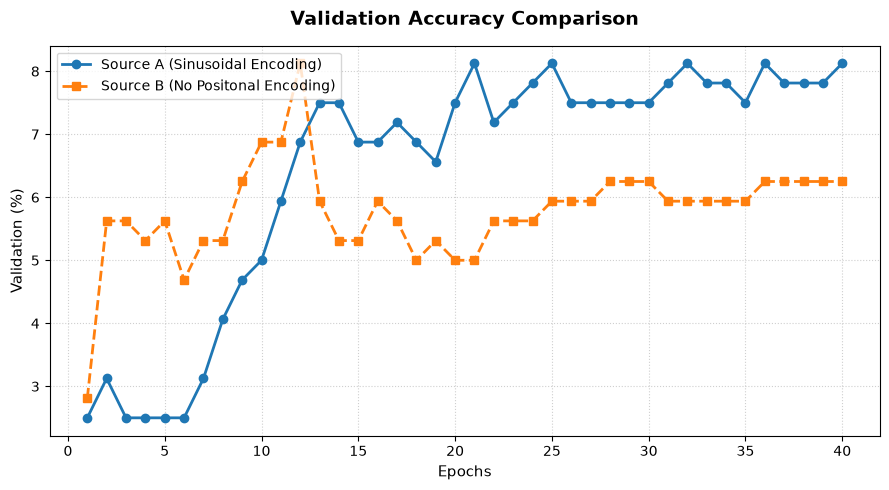

In [24]:
import matplotlib.pyplot as plt

# 1. Define shared X-axis and data points for both sources
epochs = list(range(1, 41))

source_a_pe = [d["val_accuracy"] for d in sinusoidal_data] 
source_b_no_pe = [d["val_accuracy"] for d in no_pe_data] 
# 2. Configure graph layout
plt.figure(figsize=(9, 5))

# 3. Plot both lines using explicit labels, colors, and markers
plt.plot(epochs, source_a_pe, color='#1f77b4', marker='o', linewidth=2, label='Source A (Sinusoidal Encoding)')
plt.plot(epochs, source_b_no_pe, color='#ff7f0e', marker='s', linewidth=2, linestyle='--', label='Source B (No Positonal Encoding)')

# 4. Enhance readability with titles and labels
plt.title("Validation Accuracy Comparison", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Epochs", fontsize=11)
plt.ylabel("Validation (%)", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

# 5. Add a legend to differentiate the sources
plt.legend(loc='upper left', frameon=True)

# 6. Render the graph
plt.tight_layout()
plt.savefig('./../experiments/pe_vs_no_pe.png', dpi=300, bbox_inches='tight')

plt.show()


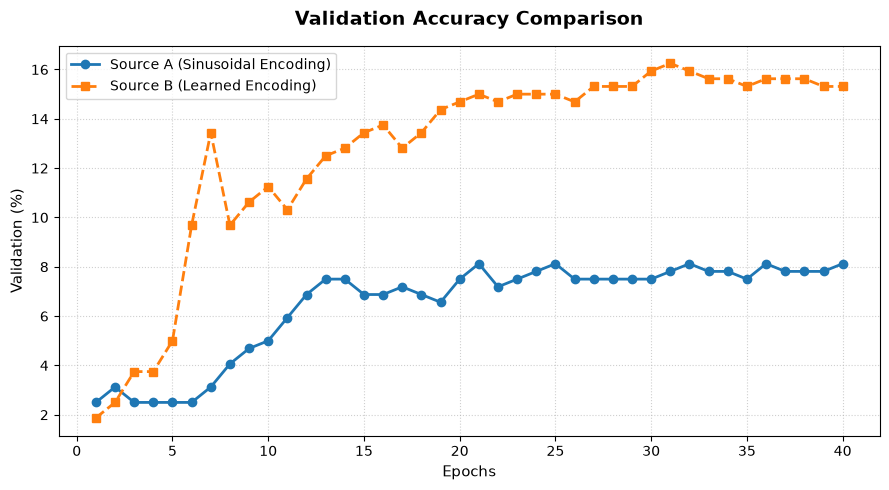

In [25]:
import matplotlib.pyplot as plt

# 1. Define shared X-axis and data points for both sources
epochs = list(range(1, 41))

source_a_pe = [d["val_accuracy"] for d in sinusoidal_data] 
source_b_learned = [d["val_accuracy"] for d in learned_data] 
# 2. Configure graph layout
plt.figure(figsize=(9, 5))

# 3. Plot both lines using explicit labels, colors, and markers
plt.plot(epochs, source_a_pe, color='#1f77b4', marker='o', linewidth=2, label='Source A (Sinusoidal Encoding)')
plt.plot(epochs, source_b_learned, color='#ff7f0e', marker='s', linewidth=2, linestyle='--', label='Source B (Learned Encoding)')

# 4. Enhance readability with titles and labels
plt.title("Validation Accuracy Comparison", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Epochs", fontsize=11)
plt.ylabel("Validation (%)", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

# 5. Add a legend to differentiate the sources
plt.legend(loc='upper left', frameon=True)

# 6. Render the graph
plt.tight_layout()
plt.savefig('./../experiments/sinusoidal_vs_learned.png', dpi=300, bbox_inches='tight')

plt.show()
